In [1]:
import pandas as pd
from multiprocessing import Pool, cpu_count

In [2]:
def parse_arguments(args=None):
    """Parse command-line arguments or use provided args."""
    import argparse
    import importlib.util
    import json

    if args is None:
        parser = argparse.ArgumentParser()
        parser.add_argument("--inp-col", type=str, required=True, help="Input column name in the DataFrame")
        parser.add_argument("--out-col", type=str, required=True, help="Output column name for LLM responses")
        parser.add_argument("--prompt-name", type=str, required=True, help="Name of the prompt to use")
        parser.add_argument("--llm-name", type=str, default="gpt-4o-mini", help="Name of the LLM to use")
        parser.add_argument("--debug-mode", action="store_true", help="Run in debug mode with sequential processing")
        
        args = parser.parse_args()

    # Read API key if not already set
    if not hasattr(args, "api_key"):
        args.api_key = read_api_key()

    # Load config and merge into args
    config_path = "configs/constants_labeling.py"
    spec = importlib.util.spec_from_file_location("constants_labeling", config_path)
    config = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(config)

    # Set attributes from config if not already set by args
    for attr in dir(config):
        if not attr.startswith("__"):
            if not hasattr(args, attr):
                setattr(args, attr, getattr(config, attr))

    # Load prompt template if not already set
    if not hasattr(args, "prompt_template"):
        args.prompt_path = getattr(args, "PROMPT_PATH", None)
        with open(args.prompt_path, "r") as f:
            PROMPT_TEMPLATES = json.load(f)
        args.prompt_template = PROMPT_TEMPLATES[args.prompt_name]

    return args

def read_api_key(api_key_path="portkey_api_key.txt"):
    """Read Portkey API key from file."""
    with open(api_key_path, "r") as f:
        return f.read().strip()

def _worker(args_tuple):
    """Worker function for multiprocessing."""
    sentence, prompt_template, model_to_be_used, api_key, prompt_name = args_tuple
    try:
        from portkey_ai import Portkey
        client = Portkey(api_key=api_key)
        
        prompt = [
            {"role": "system", "content": "You are helping in scientific analysis, so please be precise."},
            {"role": "user", "content": prompt_template.format(sentence=sentence)}
        ]
        
        # Adjust max_tokens based on prompt_name and model_to_be_used
        if "eval" in prompt_name and "Mistral" in model_to_be_used:
            max_tokens = 5
        elif "eval" in prompt_name:
            max_tokens = 1
        else:
            max_tokens = 1000
            
        response = client.chat.completions.create(
            model=model_to_be_used,
            temperature=0.0,
            max_tokens=max_tokens,
            top_p=1.0,  # Ensure top_p is 1.0 for greedy sampling
            messages=prompt
        )
        return response.choices[0].message.content
    except Exception as e:
        # print exception and return empty string
        # print(f"Error processing sentence '{sentence}': {e}")
        return ""

def call_llm_on_sentences(sentences, args, batch_size=32):
    """Call LLM on sentences and return results."""
    args_list = [
        (sent, args.prompt_template, args.llm_name, args.api_key, args.prompt_name)
        for sent in sentences
    ]
    if args.debug_mode:
        # Sequential processing for debug mode
        results = []
        for arg in args_list:
            tmp_res = _worker(arg)
            results.append(tmp_res)
    else:
        # Parallel processing
        with Pool(processes=min(cpu_count(), batch_size)) as pool:
            results = pool.map(_worker, args_list)
    return results

def process_comments_with_llm(comments_df, args, batch_size=32):
    """
    Process comments in comments_df using an LLM and store the responses in a new column.

    Args:
        comments_df (pd.DataFrame): DataFrame containing comments to process.
        args: Arguments required for the LLM call.
        batch_size (int): Number of processes to run in parallel.

    Returns:
        pd.DataFrame: DataFrame with an additional column for LLM responses.
    """
    # Extract the comments as a list
    sentences = comments_df[args.inp_col].tolist()

    # Call the LLM on the sentences
    responses = call_llm_on_sentences(sentences, args, batch_size=batch_size)

    # Add the responses as a new column in the DataFrame
    comments_df[args.out_col] = responses

    return comments_df

In [3]:
# Load comments data
comments_df = pd.read_csv('/home/sd2836/youtube_music_output/20260118_40000.csv')
comments_df.dropna(subset=['content'], inplace=True)

# # iterate through df based on 'Song Name'
# for song_name, group in comments_df.groupby('Song Name'):
#     print(f"Processing comments for song: {song_name}")
#     print(group.shape)

In [11]:
import argparse

# Manually define the arguments
args = argparse.Namespace(
    inp_col="content",
    prompt_name="eval_fandom",
    llm_name="gpt-4o-mini",
    debug_mode=False
)
args.out_col = f"{args.prompt_name}_{args.llm_name}"
args = parse_arguments(args)

# comments_df = comments_df.iloc[:50]  # For testing, limit to first 50 comments

processed_df = process_comments_with_llm(comments_df, args, batch_size=16)

# processed_df.to_csv('data/Comments_Dataset_with_LLM_Responses.csv', index=False)

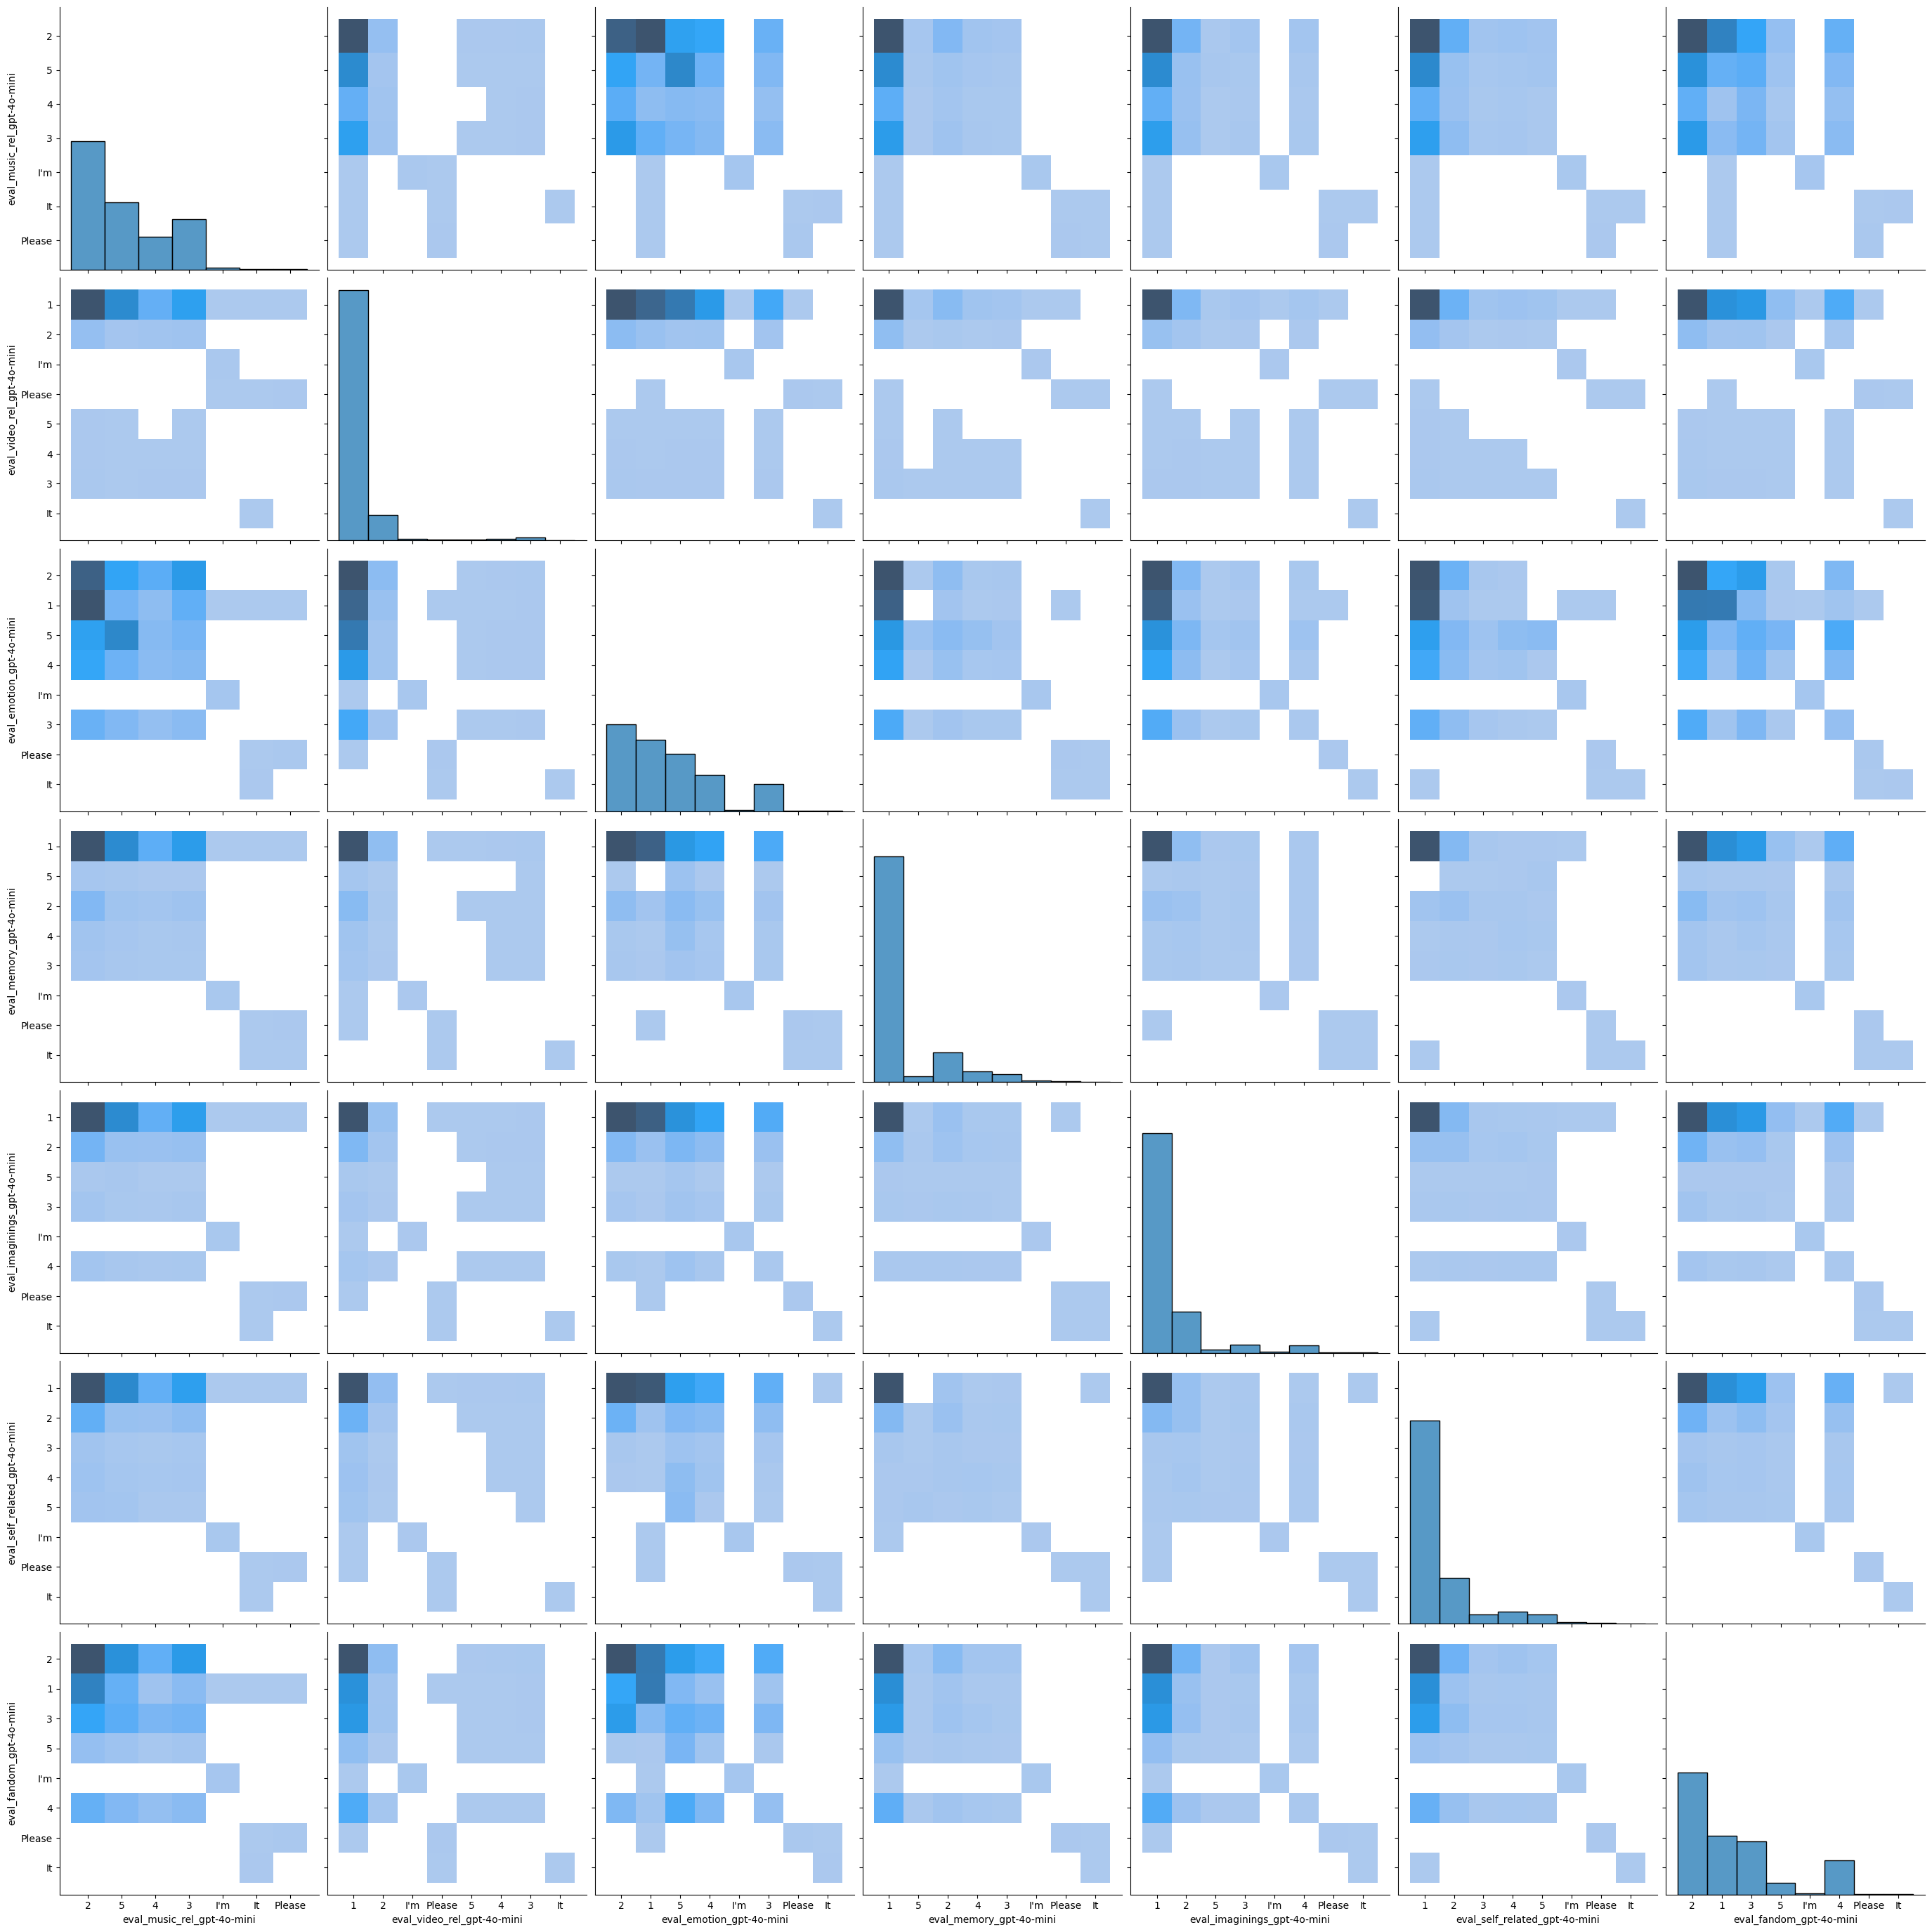

In [25]:
import seaborn as sns

ratings_df = pd.read_csv("/home/sd2836/youtube-music-comments/comments_df_40000.csv")

ratings_df = ratings_df[
    ratings_df["eval_music_rel_gpt-4o-mini"].str.strip() != "1"
]

ratings_df = ratings_df.reset_index(drop=True)

sns.pairplot(
    ratings_df,
    x_vars=["eval_music_rel_gpt-4o-mini", "eval_video_rel_gpt-4o-mini", "eval_emotion_gpt-4o-mini", "eval_memory_gpt-4o-mini", "eval_imaginings_gpt-4o-mini","eval_self_related_gpt-4o-mini","eval_fandom_gpt-4o-mini"],
    y_vars=["eval_music_rel_gpt-4o-mini", "eval_video_rel_gpt-4o-mini", "eval_emotion_gpt-4o-mini", "eval_memory_gpt-4o-mini", "eval_imaginings_gpt-4o-mini","eval_self_related_gpt-4o-mini","eval_fandom_gpt-4o-mini"],
    kind="hist",
    height=4
)



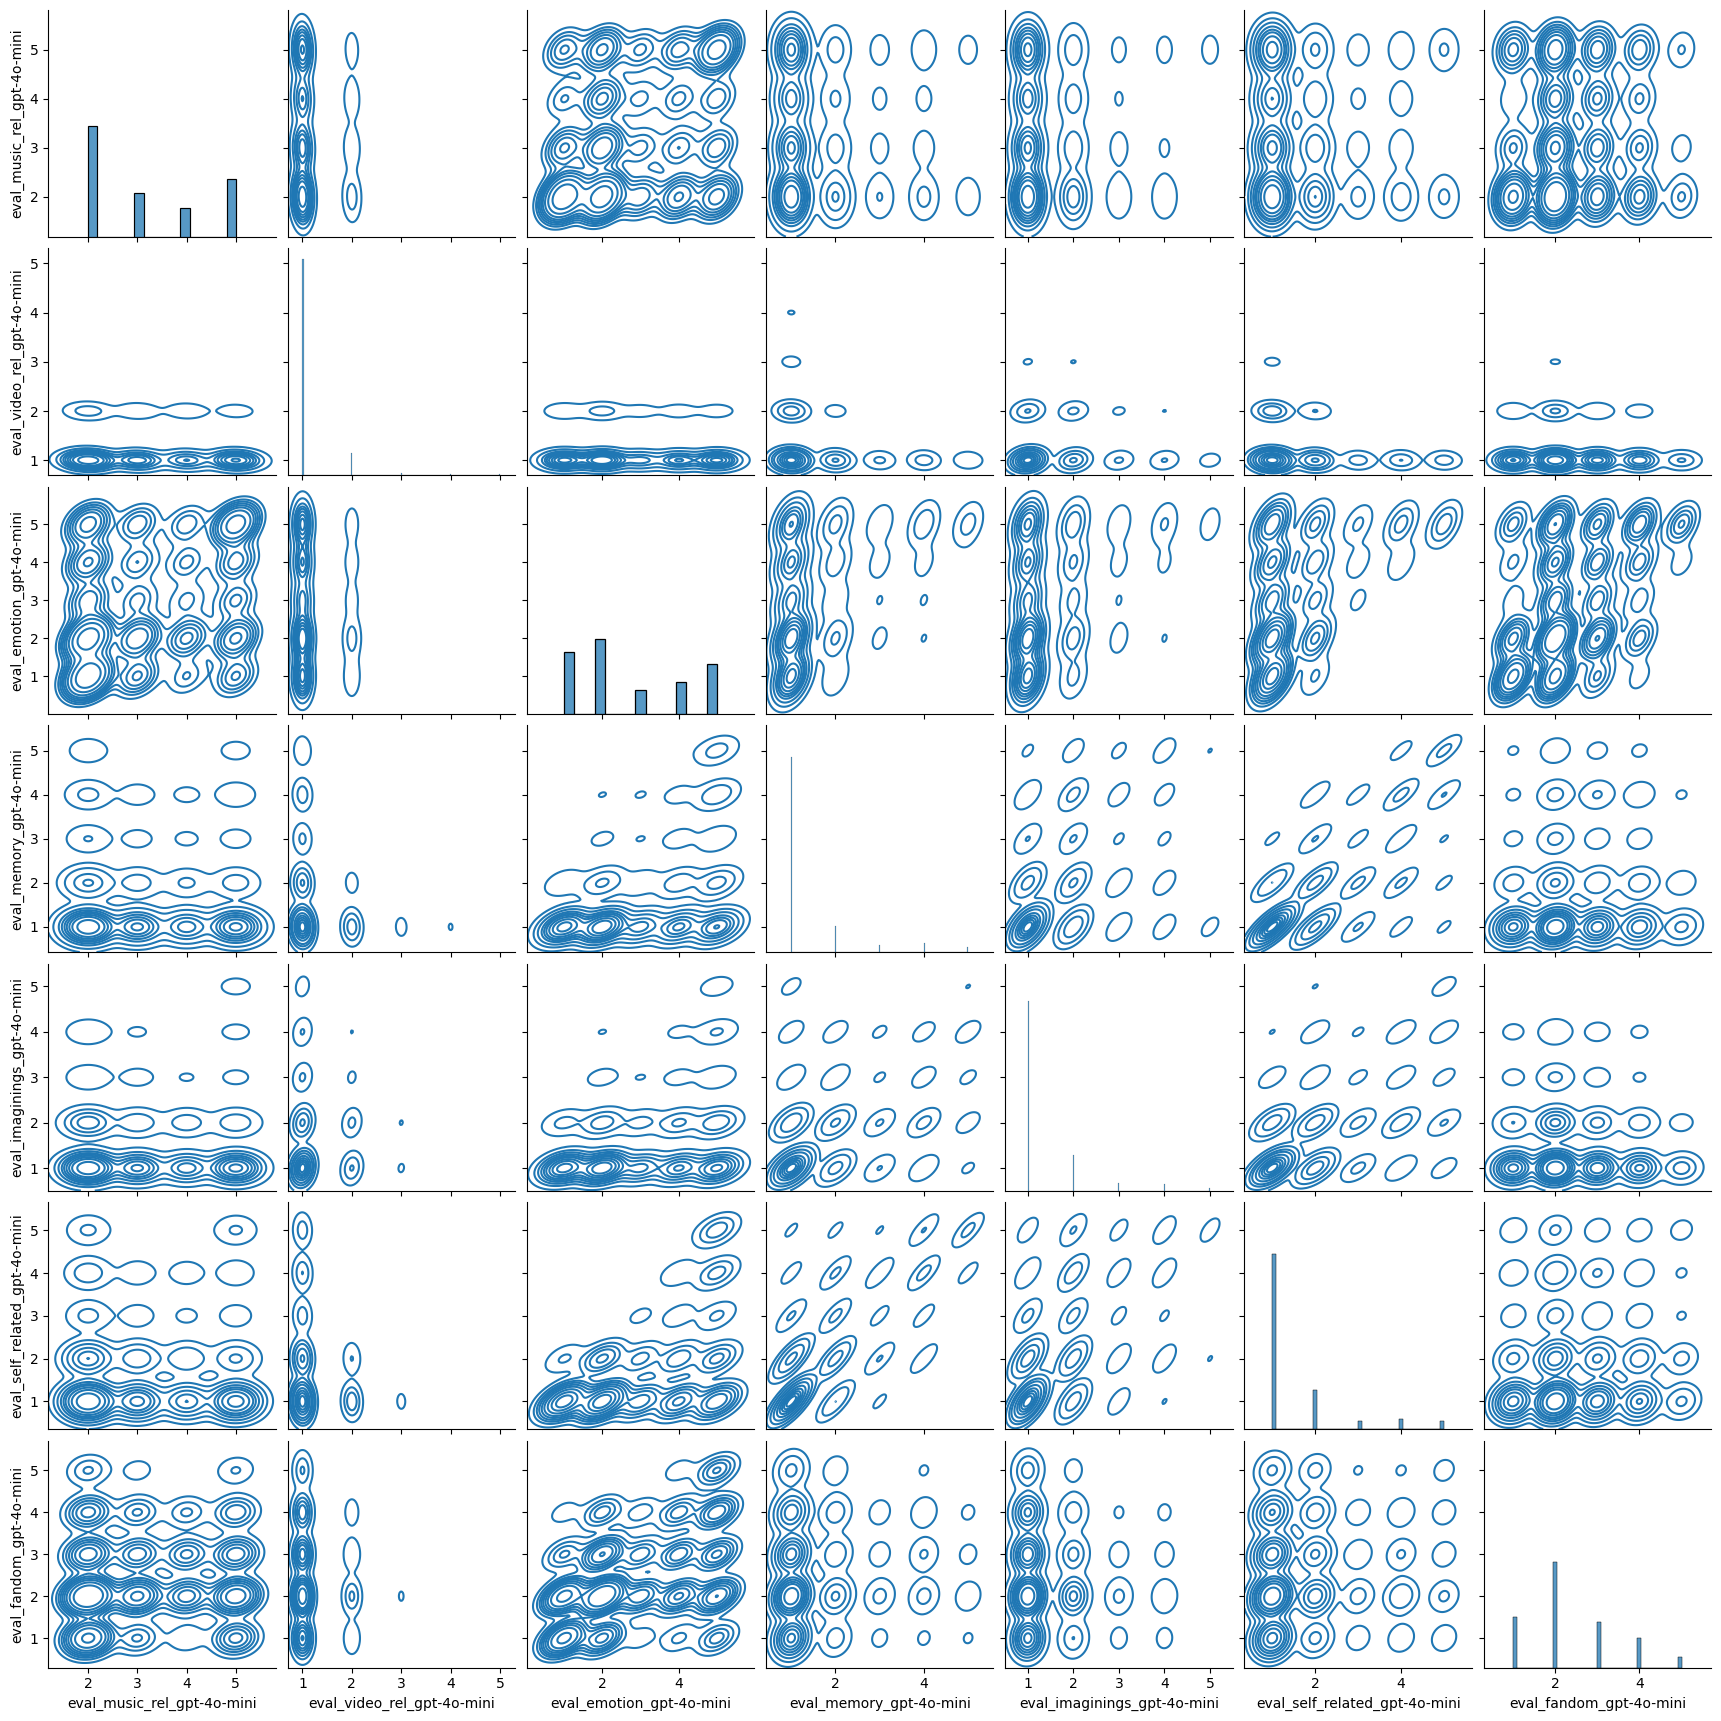

In [27]:
eval_cols = ratings_df.filter(like="eval").columns

ratings_df[eval_cols] = ratings_df[eval_cols].apply(
    pd.to_numeric, errors="coerce"
)

sns.pairplot(
    ratings_df,
    x_vars=["eval_music_rel_gpt-4o-mini", "eval_video_rel_gpt-4o-mini", "eval_emotion_gpt-4o-mini", "eval_memory_gpt-4o-mini", "eval_imaginings_gpt-4o-mini","eval_self_related_gpt-4o-mini","eval_fandom_gpt-4o-mini"],
    y_vars=["eval_music_rel_gpt-4o-mini", "eval_video_rel_gpt-4o-mini", "eval_emotion_gpt-4o-mini", "eval_memory_gpt-4o-mini", "eval_imaginings_gpt-4o-mini","eval_self_related_gpt-4o-mini","eval_fandom_gpt-4o-mini"],
    kind="kde",
    diag_kind="hist"
)

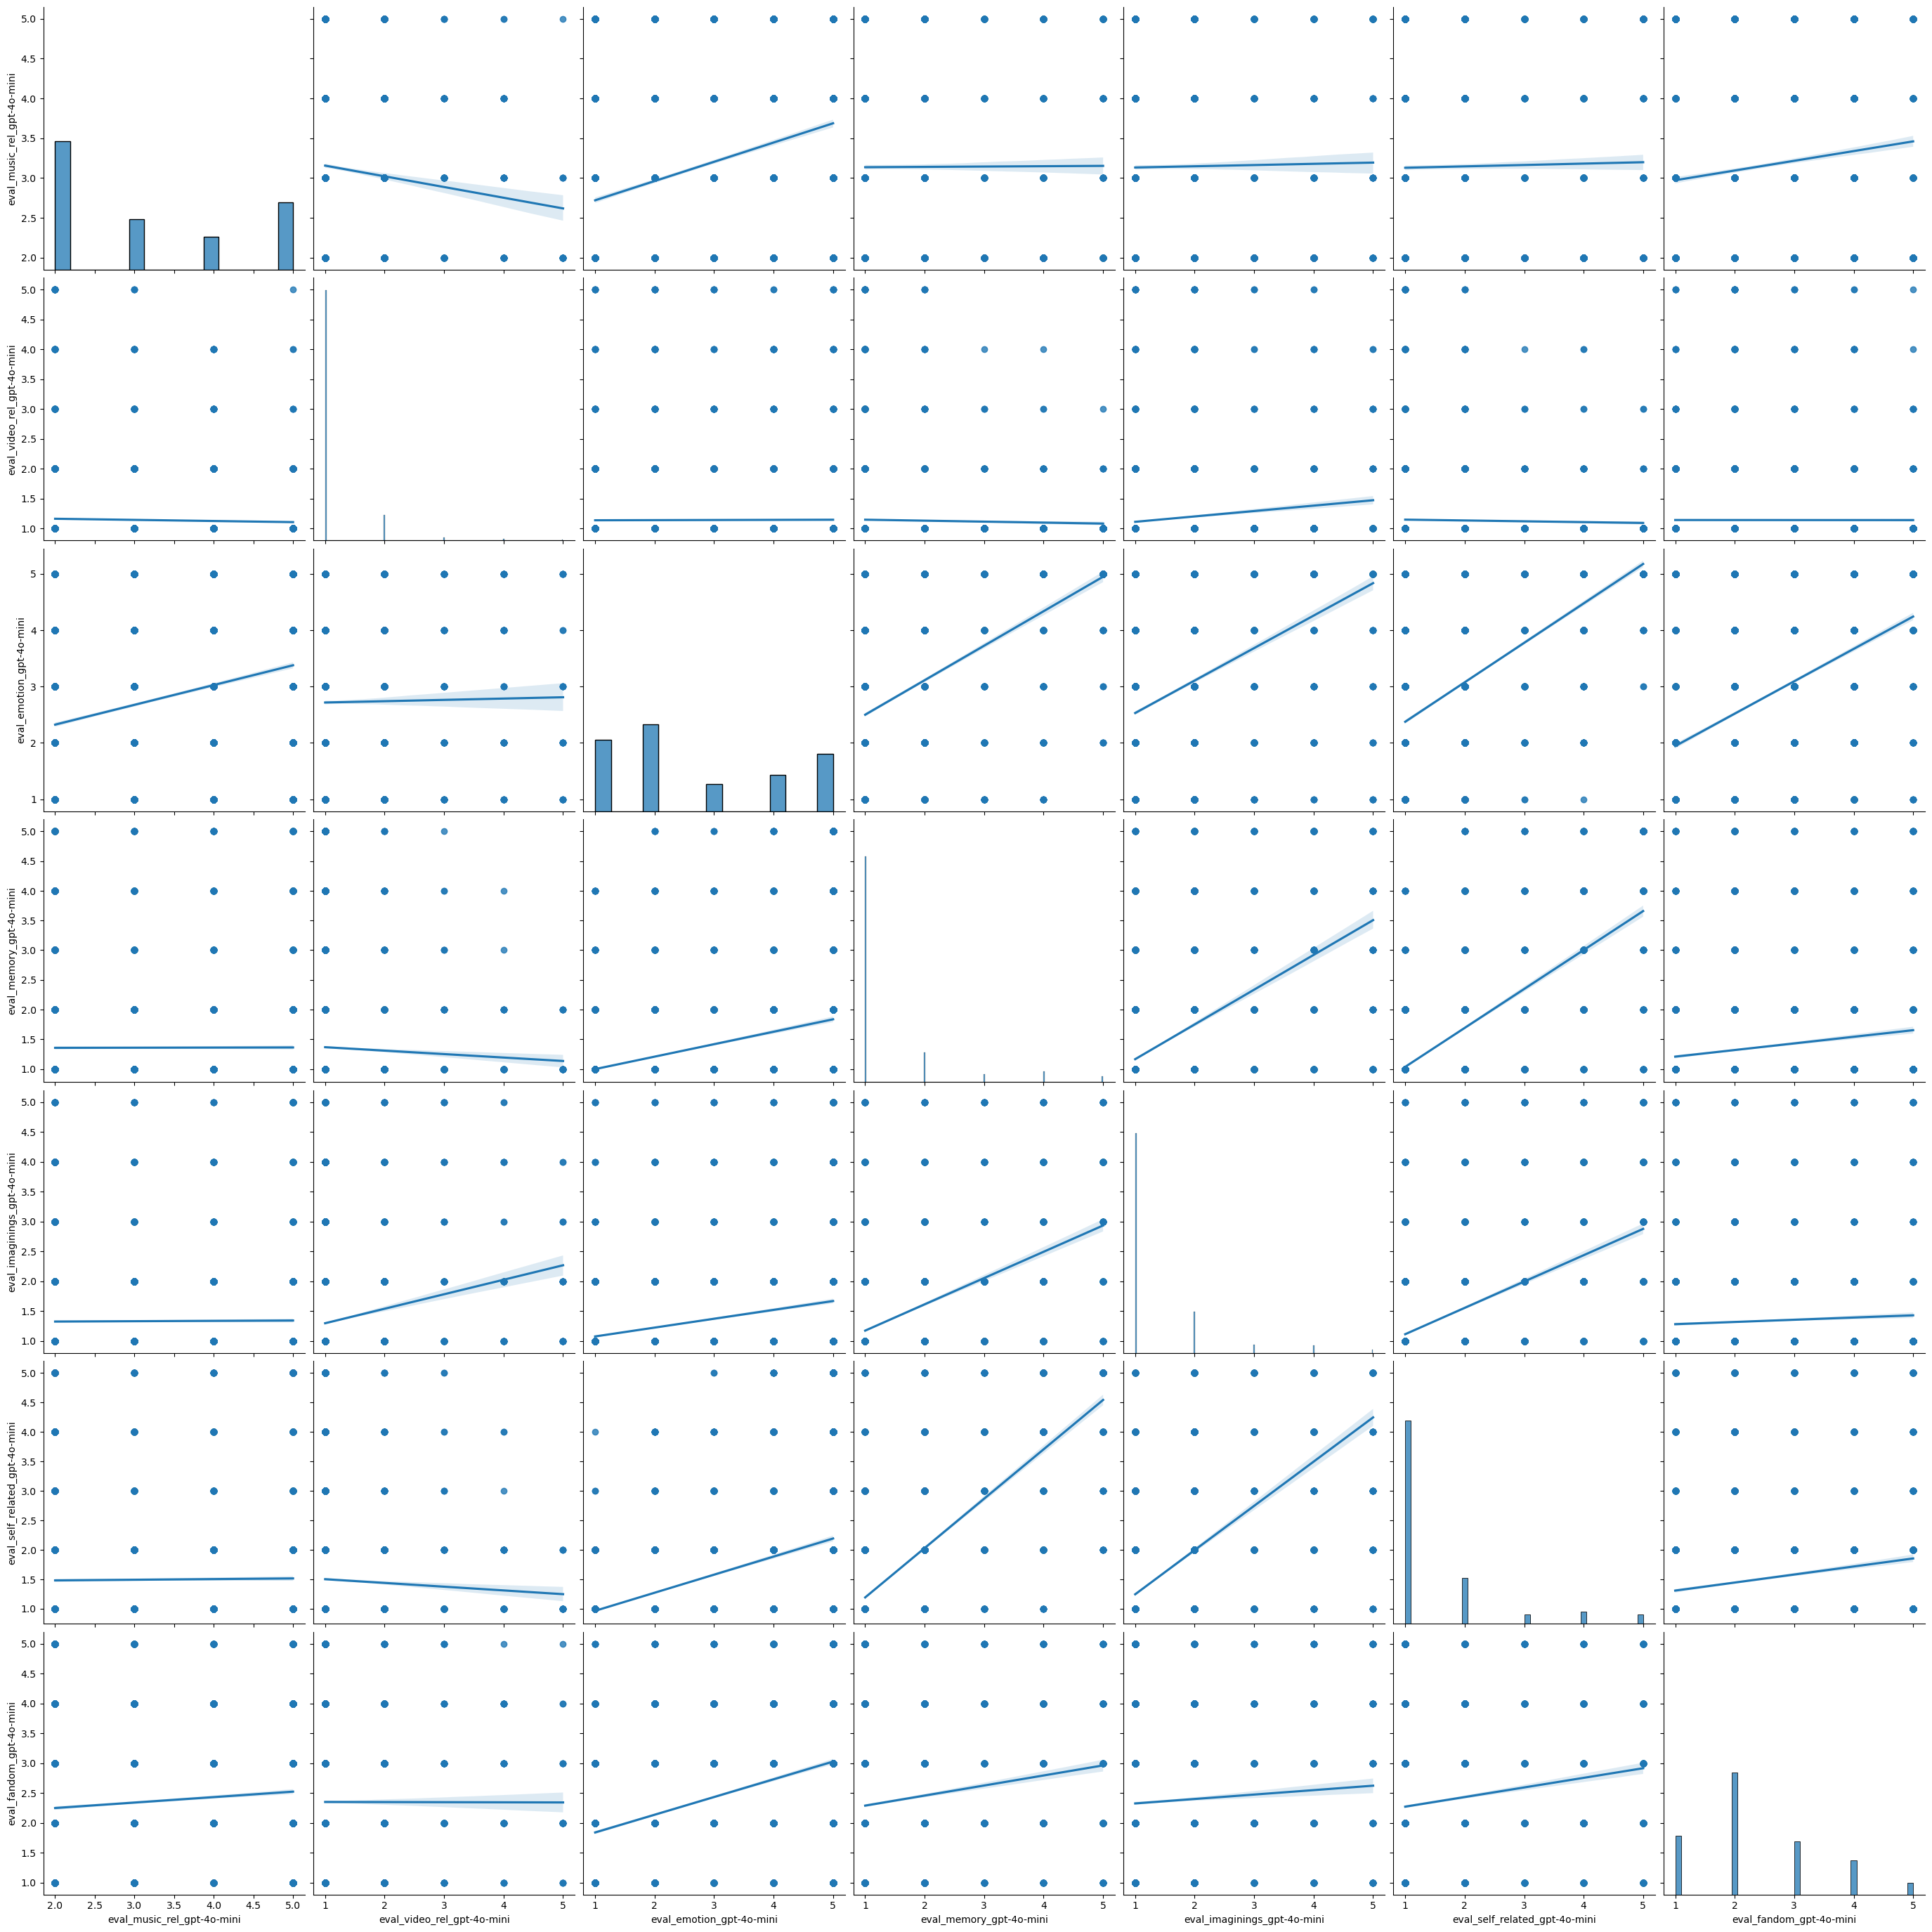

In [29]:
sns.pairplot(
    ratings_df,
    x_vars=["eval_music_rel_gpt-4o-mini", "eval_video_rel_gpt-4o-mini", "eval_emotion_gpt-4o-mini", "eval_memory_gpt-4o-mini", "eval_imaginings_gpt-4o-mini","eval_self_related_gpt-4o-mini","eval_fandom_gpt-4o-mini"],
    y_vars=["eval_music_rel_gpt-4o-mini", "eval_video_rel_gpt-4o-mini", "eval_emotion_gpt-4o-mini", "eval_memory_gpt-4o-mini", "eval_imaginings_gpt-4o-mini","eval_self_related_gpt-4o-mini","eval_fandom_gpt-4o-mini"],
    kind="reg",
    diag_kind="hist",
    height=4
)

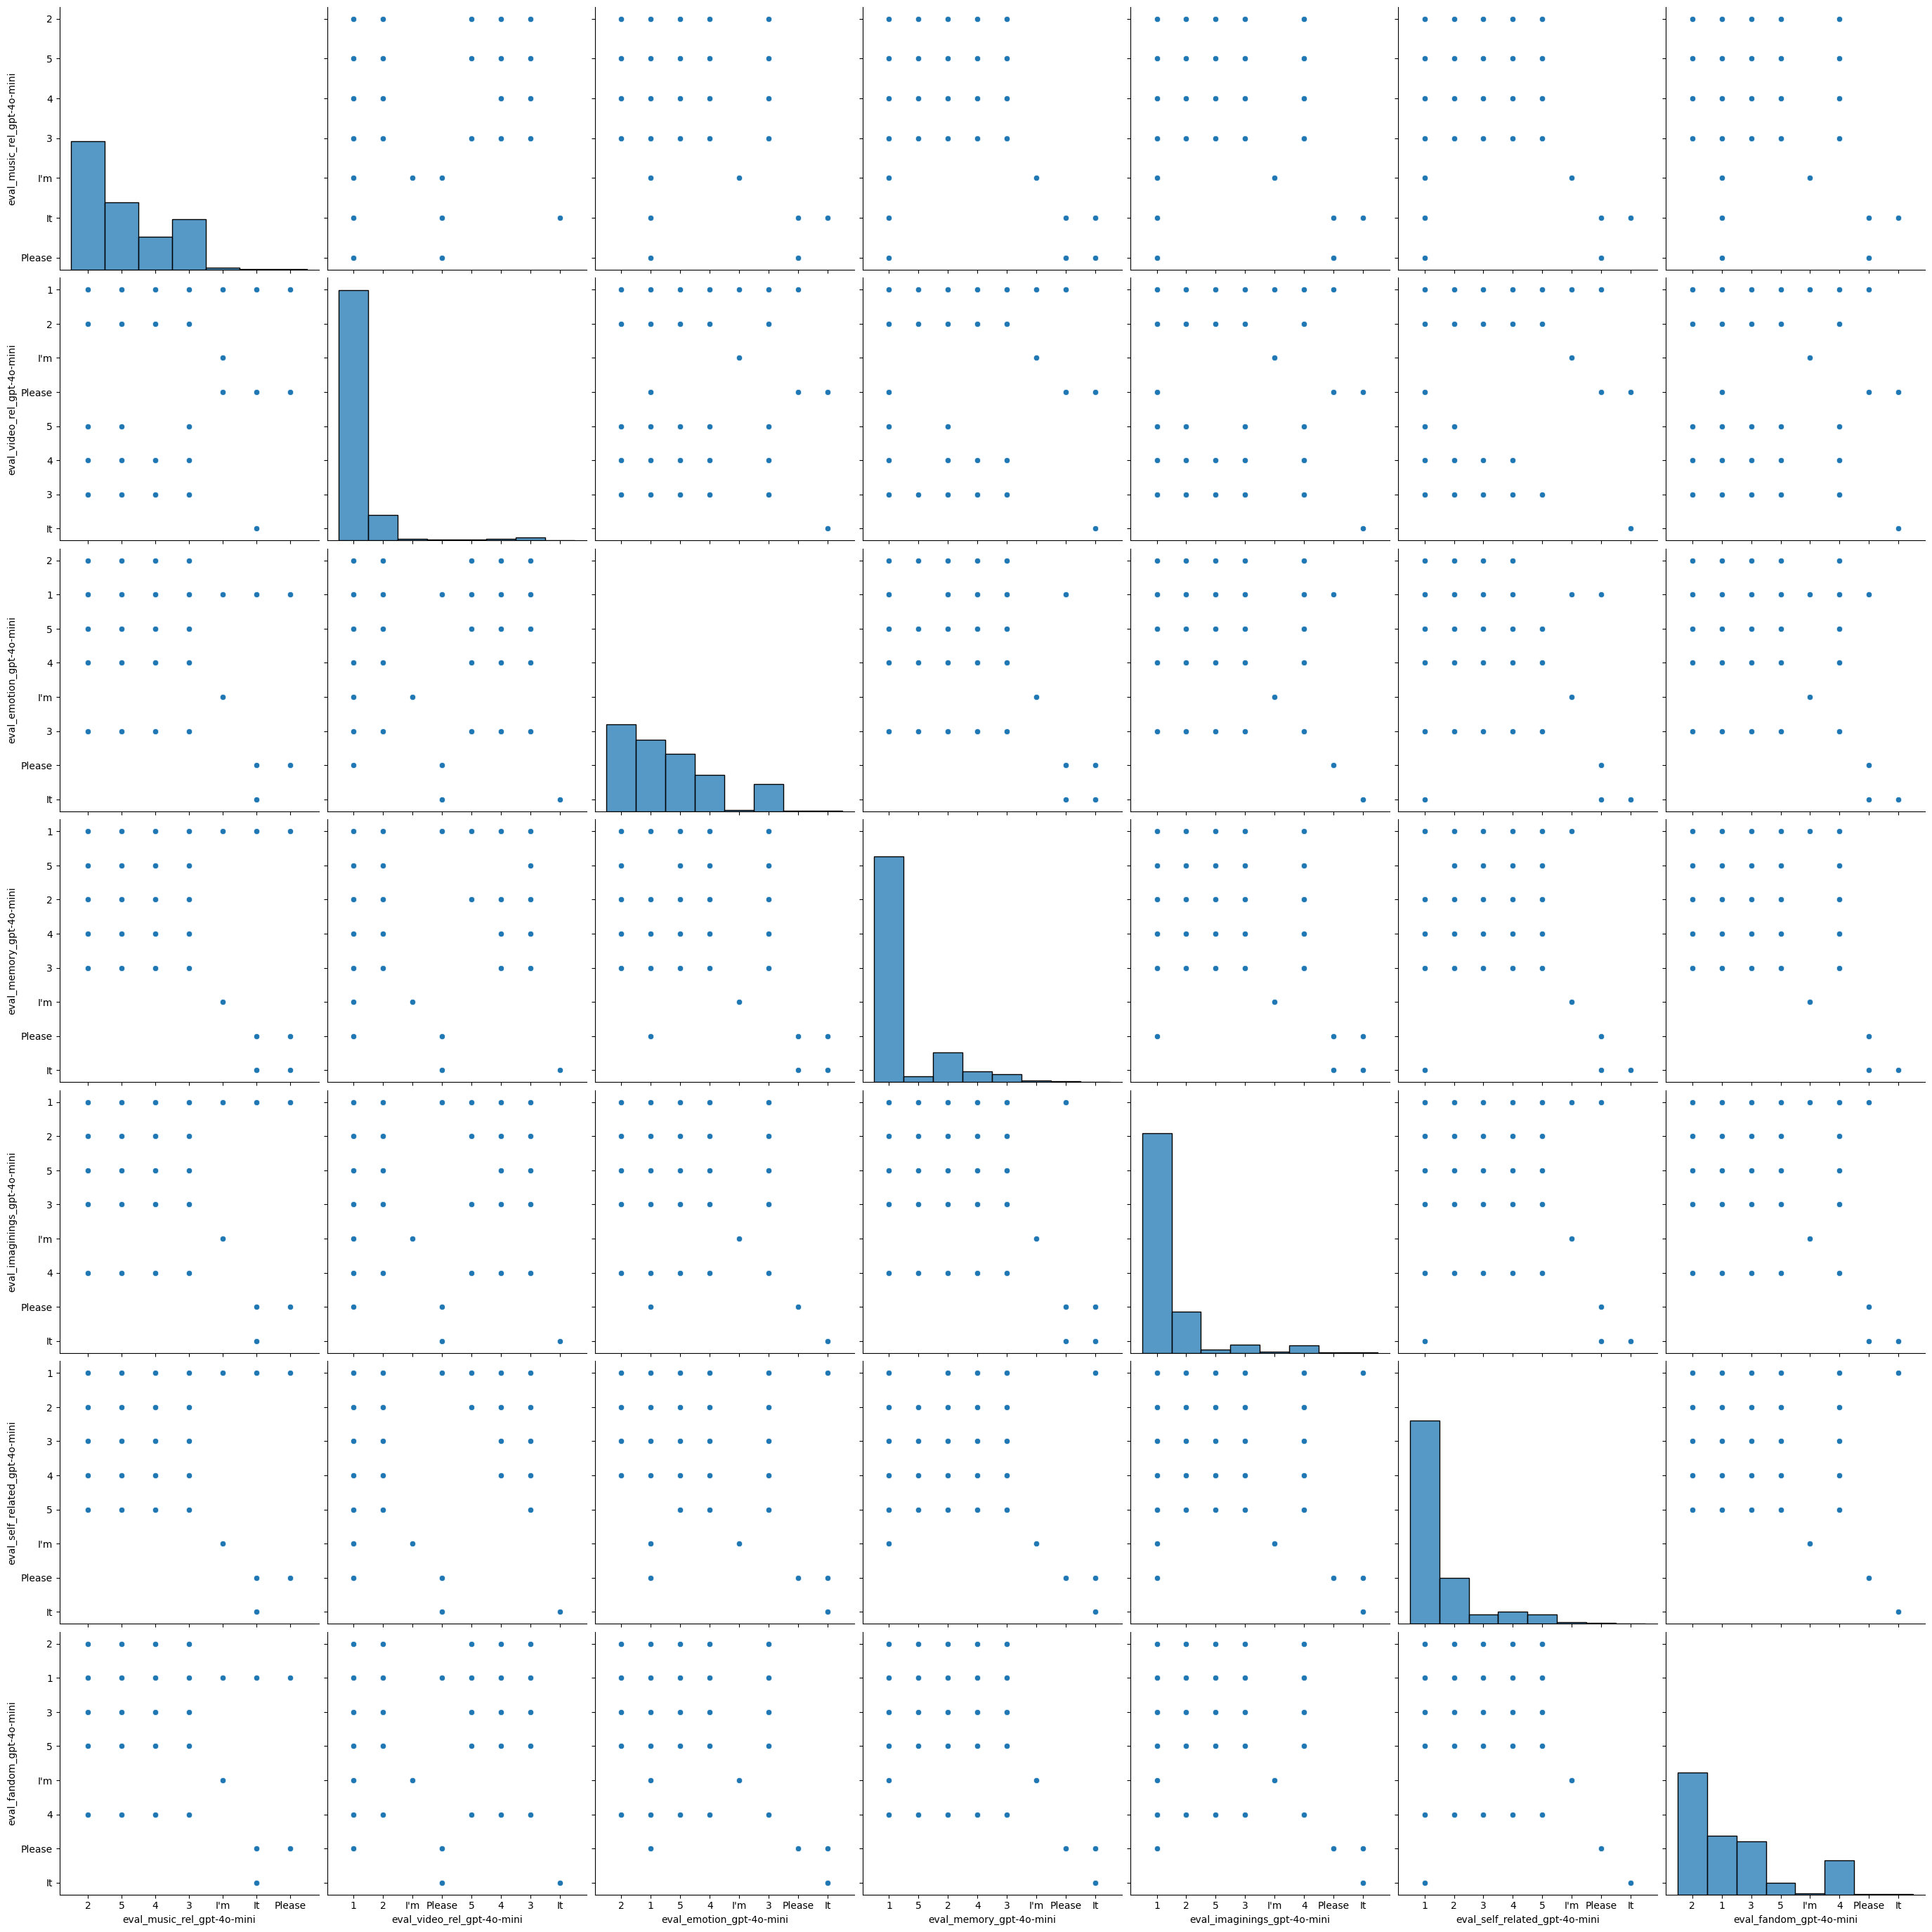

In [13]:
sns.pairplot(
    ratings_df,
    x_vars=["eval_music_rel_gpt-4o-mini", "eval_video_rel_gpt-4o-mini", "eval_emotion_gpt-4o-mini", "eval_memory_gpt-4o-mini", "eval_imaginings_gpt-4o-mini","eval_self_related_gpt-4o-mini","eval_fandom_gpt-4o-mini"],
    y_vars=["eval_music_rel_gpt-4o-mini", "eval_video_rel_gpt-4o-mini", "eval_emotion_gpt-4o-mini", "eval_memory_gpt-4o-mini", "eval_imaginings_gpt-4o-mini","eval_self_related_gpt-4o-mini","eval_fandom_gpt-4o-mini"],
    height=4
)

<Axes: >

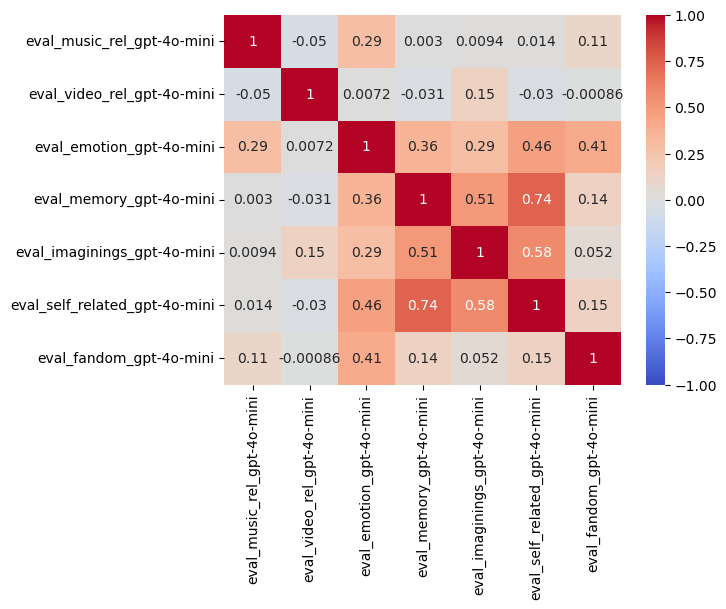

In [34]:
eval_cols = ratings_df.filter(like="eval").columns
corr = ratings_df[eval_cols].corr()

sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, annot=True)

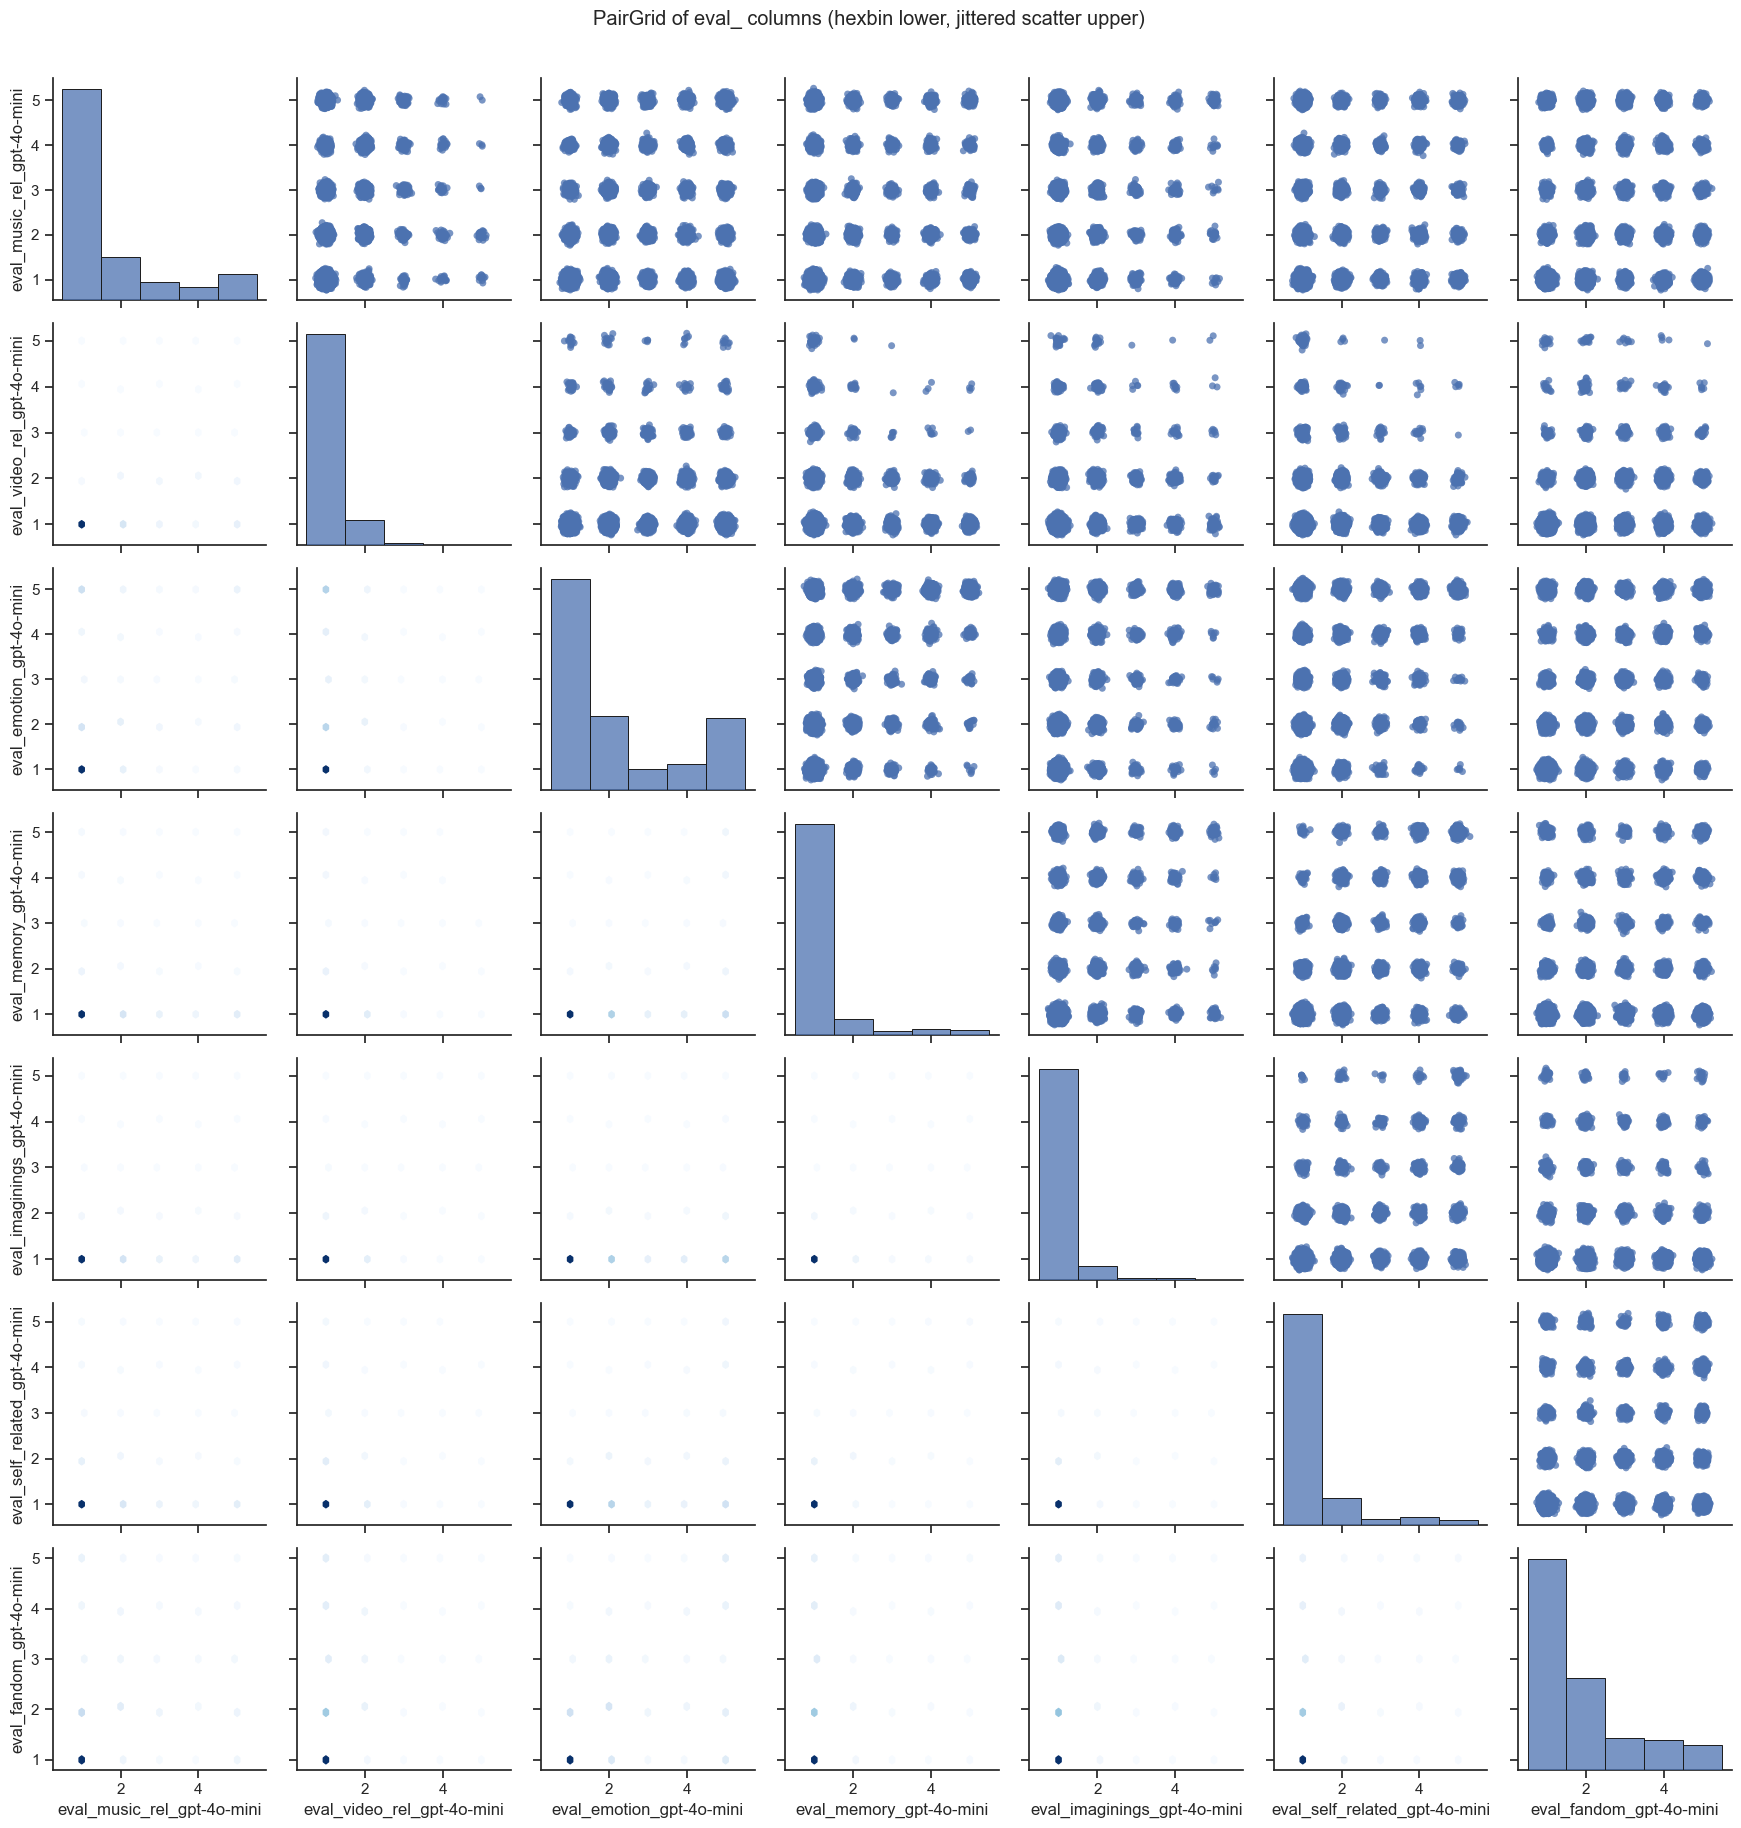

In [21]:
# ...existing code...
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = processed_df.copy()
pair_cols = [c for c in df.columns if c.startswith("eval_")]
for c in pair_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
plot_df = df[pair_cols]

sns.set(style="ticks")

def scatter_jitter(x, y, jitter=0.06, s=25, alpha=0.75, marker='o',
                   edgecolors='none', zorder=3, rasterized=False, **kwargs):
    xa = np.asarray(x)
    ya = np.asarray(y)
    mask = (~np.isnan(xa)) & (~np.isnan(ya))
    if mask.sum() == 0:
        return
    rng = np.random.default_rng(42)
    xj = xa[mask] + rng.normal(0, jitter, size=mask.sum())
    yj = ya[mask] + rng.normal(0, jitter, size=mask.sum())
    plt.scatter(xj, yj, s=s, alpha=alpha, marker=marker,
                edgecolors=edgecolors, linewidths=0, zorder=zorder,
                rasterized=rasterized, **kwargs)

def hexbin_pair(x, y, gridsize=30, cmap='Blues', mincnt=1, rasterized=True, **kwargs):
    xa = np.asarray(x)
    ya = np.asarray(y)
    mask = (~np.isnan(xa)) & (~np.isnan(ya))
    if mask.sum() == 0:
        return
    plt.hexbin(xa[mask], ya[mask], gridsize=gridsize, cmap=cmap, mincnt=mincnt, rasterized=rasterized)

g = sns.PairGrid(plot_df, diag_sharey=False)
g.map_diag(sns.histplot, bins=[0.5,1.5,2.5,3.5,4.5,5.5], edgecolor='k', linewidth=0.7)
g.map_lower(hexbin_pair)
g.map_upper(scatter_jitter)

g.fig.suptitle("PairGrid of eval_ columns (hexbin lower, jittered scatter upper)", y=1.02)
g.fig.set_size_inches(18, 18)
plt.savefig('/home/sd2836/pairgrid_eval_columns_density.png', dpi=150, bbox_inches='tight')
plt.show()
# ...existing code...

In [ ]:
# ...existing code...
# get percentage distribution of ratings 1-5 per channel (no plotting)
label_col = 'eval_fandom_gpt-4o-mini'   # replace with args.out_col if needed

df = processed_df.dropna(subset=['channel_id', label_col]).copy()
df['rating'] = pd.to_numeric(df[label_col], errors='coerce')   # ensure numeric
df = df[df['rating'].between(1, 5)]                             # keep 1-5

# totals per channel
totals = df.groupby('channel_id').size().rename('total').reset_index()

# counts per channel x rating
counts = df.groupby(['channel_id', 'rating']).size().reset_index(name='count')

# ensure every channel has rows for ratings 1-5
all_idx = pd.MultiIndex.from_product([totals['channel_id'].unique(), [1,2,3,4,5]],
                                     names=['channel_id','rating'])
counts = counts.set_index(['channel_id','rating']).reindex(all_idx, fill_value=0).reset_index()

# merge totals and compute percent
counts = counts.merge(totals, on='channel_id', how='left')
counts['percent'] = counts['count'] / counts['total'] * 100
counts['percent'] = counts['percent'].fillna(0).round(2)

# table: channel_id, rating, count, total, percent
print(counts.head(50))



                  channel_id  rating  count  total  percent
0   UC1SqP7_RfOC9Jf9L_GRHANg     1.0    517    989    52.28
1   UC1SqP7_RfOC9Jf9L_GRHANg     2.0    238    989    24.06
2   UC1SqP7_RfOC9Jf9L_GRHANg     3.0     80    989     8.09
3   UC1SqP7_RfOC9Jf9L_GRHANg     4.0     79    989     7.99
4   UC1SqP7_RfOC9Jf9L_GRHANg     5.0     75    989     7.58
5   UC5Z010wx1Yy_sQA6wNji93w     1.0    667    990    67.37
6   UC5Z010wx1Yy_sQA6wNji93w     2.0    226    990    22.83
7   UC5Z010wx1Yy_sQA6wNji93w     3.0     63    990     6.36
8   UC5Z010wx1Yy_sQA6wNji93w     4.0     31    990     3.13
9   UC5Z010wx1Yy_sQA6wNji93w     5.0      3    990     0.30
10  UCEocdCKuIKLlcd_bwBnbetg     1.0    523    973    53.75
11  UCEocdCKuIKLlcd_bwBnbetg     2.0    264    973    27.13
12  UCEocdCKuIKLlcd_bwBnbetg     3.0    118    973    12.13
13  UCEocdCKuIKLlcd_bwBnbetg     4.0     49    973     5.04
14  UCEocdCKuIKLlcd_bwBnbetg     5.0     19    973     1.95
15  UCPKWE1H6xhxwPlqUlKgHb_w     1.0    

In [ ]:
# ...existing code...
# compute percent distributions for multiple target columns (music rel already used as filter)
music_col = 'eval_music_rel_gpt-4o-mini'   # filter = keep 3-5
target_cols = [
    'eval_self_related_gpt-4o-mini',  # music rel (if you also want its own distribution)
    'eval_emotion_gpt-4o-mini',
    'eval_memory_gpt-4o-mini',
    'eval_imaginings_gpt-4o-mini',
    'eval_fandom_gpt-4o-mini',
    'eval_video_rel_gpt-4o-mini'
]

# filter by music relatedness 3-5 first
df_base = processed_df.copy()
df_base['music_rating'] = pd.to_numeric(df_base[music_col], errors='coerce')
df_base = df_base[df_base['music_rating'].between(3, 5)].copy()

results = {}  # store pivot tables per column
for col in target_cols:
    # ensure numeric and valid 1-5 ratings
    df = df_base.dropna(subset=[col, 'channel_id']).copy()
    df['rating'] = pd.to_numeric(df[col], errors='coerce')
    df = df[df['rating'].between(1, 5)]

    # overall percent distribution
    overall = (df['rating'].value_counts(normalize=True).sort_index() * 100).round(2)
    print(f"\nOverall distribution (percent) for {col}:")
    print(overall.reindex([1,2,3,4,5], fill_value=0))

    # per-channel percent distribution (long -> pivot)
    totals = df.groupby('channel_id').size().rename('total').reset_index()
    counts = df.groupby(['channel_id', 'rating']).size().reset_index(name='count')

    all_idx = pd.MultiIndex.from_product([totals['channel_id'].unique(), [1,2,3,4,5]],
                                         names=['channel_id','rating'])
    counts = counts.set_index(['channel_id','rating']).reindex(all_idx, fill_value=0).reset_index()
    counts = counts.merge(totals, on='channel_id', how='left')
    counts['percent'] = (counts['count'] / counts['total'] * 100).round(2).fillna(0)

    pivot_perc = counts.pivot(index='channel_id', columns='rating', values='percent').fillna(0)
    pivot_perc.columns = [f'rating_{int(c)}_pct' for c in pivot_perc.columns]

    print(f"\nPer-channel (percent, top 10) for {col}:")
    print(pivot_perc.sort_values(by='rating_5_pct', ascending=False).head(10))  # example sort

    results[col] = pivot_perc

# optional: save each pivot to CSV
# for col, pivot in results.items():
#     pivot.to_csv(f"/home/sd2836/{col}_percent_by_channel.csv")
# ...existing code...


Overall distribution (percent) for eval_self_related_gpt-4o-mini:
rating
1    73.99
2    13.93
3     3.69
4     4.43
5     3.97
Name: proportion, dtype: float64

Per-channel (percent, top 10) for eval_self_related_gpt-4o-mini:
                          rating_1_pct  rating_2_pct  rating_3_pct  \
channel_id                                                           
UCPKWE1H6xhxwPlqUlKgHb_w         59.63         18.01          3.73   
UC1SqP7_RfOC9Jf9L_GRHANg         56.41         16.41          7.69   
UChEYVadfkMCfrKUi6qr3I1Q         69.30         14.91          5.26   
UCEocdCKuIKLlcd_bwBnbetg         80.85         16.49          1.60   
UC5Z010wx1Yy_sQA6wNji93w         84.02         13.61          0.59   
UCf2G6jDbJI3s0d5U-N9fqzg         87.13          6.93          1.98   
UCq-Fj5jknLsUf-MWSy4_brA         86.54          7.69          4.49   

                          rating_4_pct  rating_5_pct  
channel_id                                            
UCPKWE1H6xhxwPlqUlKgHb_w       

/tmp/ipykernel_986818/2150619146.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=overall.index.astype(int), y=overall.values, palette='Blues', ax=ax)


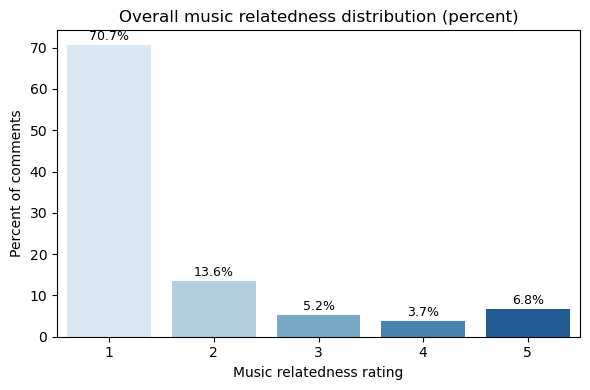

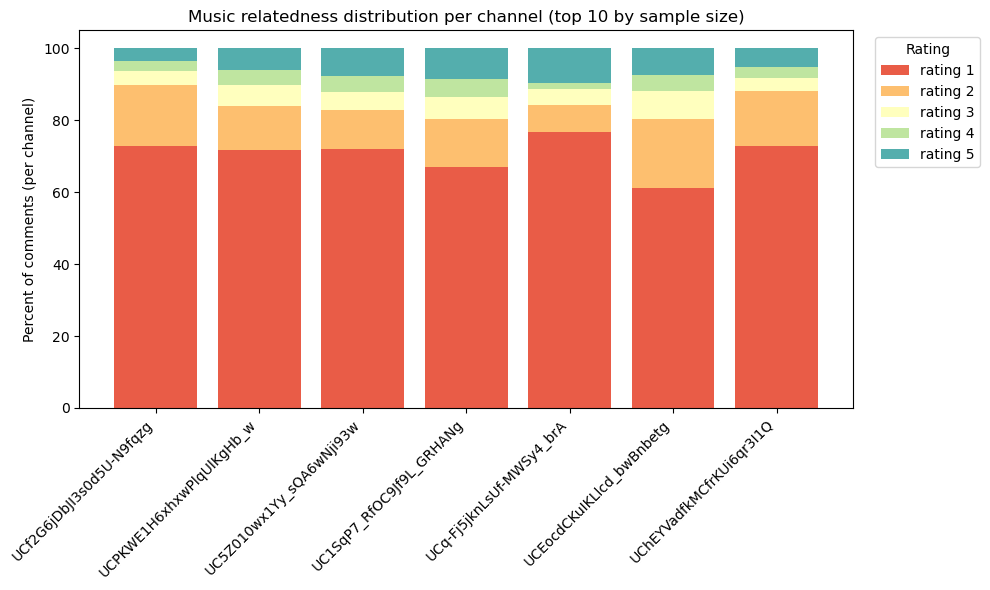

In [ ]:
# ...existing code...
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# column name
music_col = 'eval_music_rel_gpt-4o-mini'

# prepare dataframe: numeric 1-5 only
df_music = processed_df.dropna(subset=[music_col]).copy()
df_music['music_rating'] = pd.to_numeric(df_music[music_col], errors='coerce')
df_music = df_music[df_music['music_rating'].between(1, 5)]

# -- Overall histogram (percent per rating) --
overall = df_music['music_rating'].value_counts(normalize=True).reindex([1,2,3,4,5], fill_value=0) * 100
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x=overall.index.astype(int), y=overall.values, palette='Blues', ax=ax)
ax.set_xlabel('Music relatedness rating')
ax.set_ylabel('Percent of comments')
ax.set_title('Overall music relatedness distribution (percent)')
for i, v in enumerate(overall.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('/home/sd2836/music_relatedness_overall.png', dpi=150)
plt.show()

# -- Per-channel: stacked percent bars for top N channels --
N = 10  # change as needed
top_channels = df_music['channel_id'].value_counts().head(N).index

# pivot to percent per rating per channel
counts = (df_music[df_music['channel_id'].isin(top_channels)]
          .groupby(['channel_id', 'music_rating']).size()
          .unstack(fill_value=0)
          .reindex(columns=[1,2,3,4,5], fill_value=0))

perc = counts.div(counts.sum(axis=1), axis=0) * 100
perc = perc.loc[top_channels]  # ensure original order

# stacked bar plot
fig, ax = plt.subplots(figsize=(10,6))
bottom = np.zeros(len(perc))
colors = sns.color_palette('Spectral', 5)
for i, rating in enumerate([1,2,3,4,5]):
    vals = perc[rating].values
    ax.bar(perc.index.astype(str), vals, bottom=bottom, color=colors[i], label=f'rating {rating}')
    bottom += vals
ax.set_ylabel('Percent of comments (per channel)')
ax.set_title(f'Music relatedness distribution per channel (top {N} by sample size)')
ax.legend(title='Rating', bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/home/sd2836/music_relatedness_per_channel_topN.png', dpi=150)
plt.show()
# ...existing code...